In [1]:
from src import *

In [3]:
MetaData('di', 0.2, DMD.A(5), 0).convert2str()

'di_5px_f0.2_d0'

In [3]:
LoadEstimates('data/noisy/di_5px_f0.2_d100.npz').photons

array(864.247912)

In [13]:
spade_bg1 = []
di_bg1 = []
for f in glob('MLEtest/spade_5px_f0.2_*'):
    bg = qCMOS.convert2photons(np.load(f)['background']).mean()
    spade_bg1.append(bg)
for f in glob('MLEtest/di_5px_f0.2_*'):
    bg = qCMOS.convert2photons(np.load(f)['background']).mean()
    di_bg1.append(bg)

In [14]:
spade_bg = []
di_bg = []
for f in glob('data/noisy/*_5px_f0.2_*'):
    c = LoadEstimates(f)
    if c.metadata.measurement == 'SPADE':
        spade_bg.append(c.background)
    elif c.metadata.measurement == 'DI':
        di_bg.append(c.background)

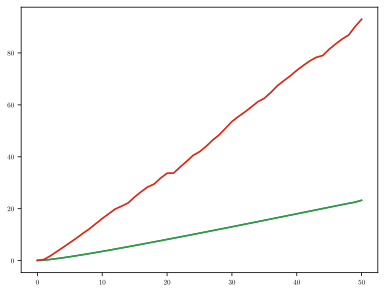

In [15]:
plt.plot(np.sort(np.array(spade_bg)))
plt.plot(np.sort(np.array(np.array(di_bg))))

plt.plot(np.sort(np.array(spade_bg1)))
plt.plot(np.sort(np.array(np.array(di_bg1))))


In [2]:
c1 = '#1f77b4'
c2 = '#2ca02c'

red = '#d62728'
width = 8.5 / 2.54

In [3]:
# def read_noisy_est():
spade_mean, spade_var, spade_b = [], [], []
di_mean, di_var, di_b = [], [], []
for d in np.arange(0, 101, 2):
    spade_c = LoadEstimates(rf'data/noisy/spade_5px_f0.2_d{d}.npz')
    di_c = LoadEstimates(rf'data/noisy/di_5px_f0.2_d{d}.npz')

    spade_mean.append(spade_c.estimates.mean())
    spade_var.append(spade_c.estimates.var(ddof=1) * spade_c.photons)
    spade_b.append(spade_c.background / spade_c.photons)

    di_mean.append(di_c.estimates.mean())
    di_var.append(di_c.estimates.var(ddof=1) * di_c.photons)
    di_b.append(di_c.background / di_c.photons)

#     return np.array(spade_mean), np.array(spade_var), np.array(spade_b), \
#            np.array(di_mean), np.array(di_var), np.array(di_b)

# spade_mean, di_mean, spade_var, di_var, spade_b, di_b = read_noisy_est()

b_axis = np.linspace(1e-10, 0.2, 1000)
spade_crb = 1/SPADE.CFI(b_axis, DMD.A(5), 0.2)
di_crb = 1/DI.CFI(b_axis, DMD.A(5), 0.2)

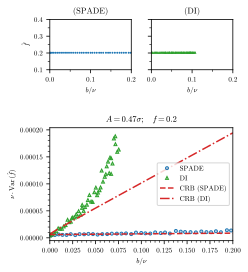

In [8]:
fig = plt.figure(figsize=(width, width*1.25))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax2.tick_params(axis='y', labelleft=False)

ax3 = fig.add_subplot(gs[1, :])

ax1.plot(spade_b, spade_mean, marker='o', linestyle='', markersize=1, 
         markeredgecolor=c1, markerfacecolor=c1)

ax2.plot(di_b, di_mean, marker='^', linestyle='', markersize=1, 
         markeredgecolor=c2, markerfacecolor=c2)

ax1.set_ylabel(r'$\hat f$')
ax1.set_yticks(np.linspace(0.1, 0.4, 4))

ax1.set_title('(SPADE)')
ax2.set_title('(DI)')

for ax_ in (ax1, ax2, ax3):
    ax_.set_box_aspect(0.618)
    ax_.set_xlim(0, 0.2)
    ax_.set_xlabel(r'$b/\nu$')
    
    if not ax_ == ax3:
        # ax_.set_ylim(0.1, 0.4)
        ax_.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax_.yaxis.set_minor_locator(AutoMinorLocator(2))

    else:
        # ax_.set_ylim(0, 2e-4)
        ax_.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_.yaxis.set_minor_locator(AutoMinorLocator(5))



ax3.plot(spade_b, spade_var, color=c1, marker='o', 
         linestyle='', markersize=3, 
         markeredgecolor=c1, markerfacecolor=(c1, 0.3),
         label='SPADE')

ax3.plot(0.7*np.array(di_b), di_var, color=c2, marker='^', 
         linestyle='', markersize=3, 
         markeredgecolor=c2, markerfacecolor=(c2, 0.3),
         label='DI')

ax3.plot(b_axis, spade_crb, linestyle='--', color=red, label='CRB (SPADE)')
ax3.plot(b_axis, di_crb, linestyle='-.', color=red, label='CRB (DI)')

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))

# ax3.yaxis.set_major_formatter(formatter)
# ax3.set_xticks(np.linspace(0, 0.2, 5))
# ax3.set_yticks(np.arange(0, 2.001, 0.5) * 1e-4)

ax3.set_title(r'$A=0.47\sigma;\quad f=0.2$')
ax3.set_ylabel(r'$\nu\cdot{\rm Var\,}(\hat f)$')
ax3.legend(loc='center right')

plt.tight_layout()
plt.savefig('noisy.svg')
plt.show()
